In [4]:
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Preprocessing and Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Configuration 
FEATURES_DATA_DIR = Path("data/03_features")
MODELS_DIR = Path("models")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("Setup complete. Libraries and paths are ready.")

Setup complete. Libraries and paths are ready.


In [9]:
# Load the tuple
X, y = joblib.load(FEATURES_DATA_DIR / "features.pkl")

# If X is not a DataFrame yet, convert it
if not isinstance(X, pd.DataFrame):
    X = pd.DataFrame(X)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Quick preview
display(X.head())
display(y.head())

Features shape: (7212, 702)
Target shape: (7212,)


,0,1,2,3,4,5,6,7,8,9,...,692,693,694,695,696,697,698,699,700,701
0,-0.020205,0.000615,0.005174,-0.082271,-0.044478,-1.182389e-01,-0.002241,0.037379,0.101726,0.022363,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.973199
1,-0.075147,0.014511,0.027234,-0.062529,-0.052275,-8.569130e-03,-0.060079,0.003124,0.028558,0.040569,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.653197
2,-0.061341,0.029005,-0.029090,-0.005162,0.002657,-8.697754e-07,-0.014805,-0.057095,0.070508,0.064989,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.301856
3,-0.042180,0.082112,-0.040893,-0.037100,0.005625,8.674259e-02,0.043857,-0.007552,0.028666,-0.013288,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.137527
4,0.072408,0.017608,-0.042918,-0.076938,-0.041888,-6.989304e-02,-0.019500,0.104806,-0.080880,0.057501,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.779382


0    CRITICAL
1      MEDIUM
2        HIGH
3        HIGH
4        HIGH
Name: Severity, dtype: object

In [10]:
print("Splitting data into training and testing sets...")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Splitting data into training and testing sets...
Training set shape: (5409, 702)
Testing set shape: (1803, 702)


In [11]:
print("Defining preprocessing pipeline...")
    
categorical_features = ['CWE']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Keep embedding columns untouched
)

print("Preprocessor defined.")

Defining preprocessing pipeline...
Preprocessor defined.


In [15]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb

# Load saved features
FEATURES_DATA_DIR = Path("data/03_features")
X_array, y = joblib.load(FEATURES_DATA_DIR / "features.pkl")  # currently a tuple of (array, target)

# Convert to DataFrame
n_features = X_array.shape[1] - 1  # last column is 'CWE' encoded or something
X_df = pd.DataFrame(X_array[:, :-1])  # numeric features
X_df['CWE'] = X_array[:, -1]          # add 'CWE' as a column

print("Features shape:", X_df.shape)
print("Target shape:", y.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessing
numeric_features = [col for col in X_df.columns if col != 'CWE']
categorical_features = ['CWE']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Stacking model
base_estimators = [
    ('lgbm', lgb.LGBMClassifier(random_state=42)),
    ('xgb', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
]
meta_classifier = LogisticRegression(max_iter=1000)

stacking_classifier = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_classifier,
    cv=5
)

# Full pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', stacking_classifier)
])

# Train
print("Training the final model... (This may take several minutes)")
full_pipeline.fit(X_train, y_train)
print("Model training complete!")


Features shape: (7212, 702)
Target shape: (7212,)
Training the final model... (This may take several minutes)


TypeError: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.

In [ ]:
print("Training the final model...")
    
base_estimators = [
    lgb.LGBMClassifier(device='gpu', gpu_platform_id=0, gpu_device_id=0, random_state=42)
    xgb.XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                  random_state=42, use_label_encoder=False, eval_metric='mlogloss')

]
meta_classifier = LogisticRegression(max_iter=1000)
stacking_classifier = StackingClassifier(
    estimators=base_estimators, final_estimator=meta_classifier, cv=5
)

# Create the full pipeline: preprocess data, then train the model
full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('classifier', stacking_classifier)])

full_pipeline.fit(X_train, y_train)

print("Model training complete.")

Training the final model... (This may take several minutes)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018294 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97960
[LightGBM] [Info] Number of data points in the train set: 1905, number of used features: 404
[LightGBM] [Info] Start training from score -2.833738
[LightGBM] [Info] Start training from score -1.090769
[LightGBM] [Info] Start training from score -3.086329
[LightGBM] [Info] Start training from score -0.580569
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:51:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012024 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97950
[LightGBM] [Info] Number of data points in the train set: 1524, number of used features: 399
[LightGBM] [Info] Start training from score -2.829284
[LightGBM] [Info] Start training from score -1.090769
[LightGBM] [Info] Start training from score -3.094987
[LightGBM] [Info] Start training from score -0.580334
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011674 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97950
[LightGBM] [Info] Number of data points in the train set: 1524, number of used features: 399
[LightGBM] [Info] Start training from score -2.829284
[LightGBM] [Info] Start training from score -1.090769
[LightGBM] [Info] Start training from score -3.094987
[LightGBM] [Info] Start training from score -0.580334
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97948
[LightGBM] [Info] Number of data points in the train set: 1524, number of used features: 398
[LightGBM] [Info] Start training from score -2.840457
[LightGBM] [Info] Start training from score -1.090769
[LightGBM] [Info] Start training from score -3.080598
[LightGBM] [Info] Start training from score -0.580334
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011803 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 97954
[LightGBM] [Info] Number of data points in the train set: 1524, number of used features: 401
[LightGBM] [Info] Start training from score -2.840457
[LightGBM] [Info] Start training from score -1.090769
[LightGBM] [Info] Start training from score -3.080598
[LightGBM] [Info] Start training from score -0.580334
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:51:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:52:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:52:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:52:24] WARN

Model training complete.


In [ ]:
print("\n--- Detailed Report for Best Model ---")
preds = full_pipeline.predict(X_test)
class_names = label_encoder.classes_
print(classification_report(y_test, preds, target_names=class_names))


--- Detailed Report for Best Model ---
              precision    recall  f1-score   support

    CRITICAL       0.80      0.11      0.19        37
        HIGH       0.61      0.53      0.57       214
         LOW       0.86      0.21      0.33        29
      MEDIUM       0.70      0.86      0.77       355

    accuracy                           0.68       635
   macro avg       0.74      0.43      0.47       635
weighted avg       0.68      0.68      0.65       635



c:\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Generating confusion matrix plot...


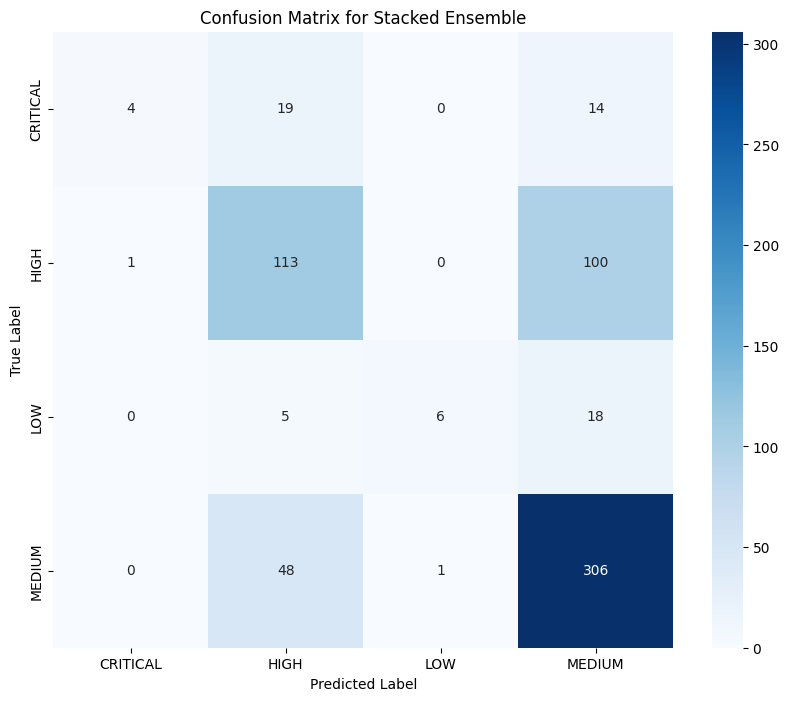

In [ ]:
print("Generating confusion matrix plot...")
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Stacked Ensemble')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig(MODELS_DIR / "best_model_confusion_matrix.png")
plt.show()

In [ ]:
print("Saving the final pipeline...")
joblib.dump(full_pipeline, MODELS_DIR / "full_pipeline.pkl")
joblib.dump(label_encoder, MODELS_DIR / "label_encoder.pkl")

print("\nModel training and evaluation complete!")

Saving the final pipeline...

Model training and evaluation complete!
